# Project 1 - First Payment Default


Setup and Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import ( roc_auc_score, average_precision_score,
    classification_report, confusion_matrix)

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

import shap
shap.initjs()

pd.set_option("display.max_columns", 200)


# Load the kaggle_dataset.csv file into a pandas DataFrame
df = pd.read_csv('/content/drive/MyDrive/kaggle_dataset.csv')

ID_COL = "ID"
TARGET = "target"


Exploratory Data Analysis  (EDA)

In [ ]:
df.shape # rows, columns
df.info() # missing values
df.columns

# Define feature columns (excluding ID and Target)
feature_cols = [c for c in df.columns if c not in [ID_COL, TARGET]]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38985 entries, 0 to 38984
Data columns (total 87 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   feature_1   38985 non-null  float64
 1   feature_2   38985 non-null  int64  
 2   feature_3   38985 non-null  int64  
 3   feature_4   38985 non-null  int64  
 4   feature_5   36771 non-null  float64
 5   feature_6   36771 non-null  float64
 6   feature_7   36771 non-null  float64
 7   feature_8   38985 non-null  int64  
 8   feature_9   38985 non-null  int64  
 9   feature_10  36771 non-null  float64
 10  feature_11  38985 non-null  float64
 11  feature_12  38985 non-null  float64
 12  feature_13  36771 non-null  float64
 13  feature_14  36771 non-null  float64
 14  feature_15  23258 non-null  float64
 15  feature_16  26095 non-null  float64
 16  feature_17  28240 non-null  float64
 17  feature_18  23258 non-null  float64
 18  feature_19  26095 non-null  float64
 19  feature_20  28240 non-nul

Missing Values - calculated the percent missing for each feature and then visualized it.

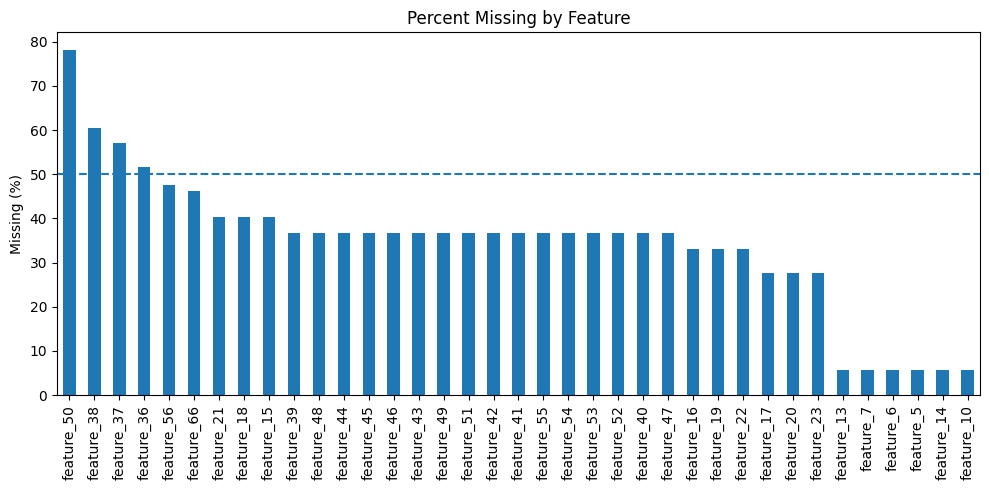

In [ ]:
#visualizing the missing values
missing_pct_plot = missing_pct[missing_pct > 0]

plt.figure(figsize=(10, 5))
missing_pct_plot.plot(kind="bar")
plt.axhline(50, linestyle="--")
plt.title("Percent Missing by Feature")
plt.ylabel("Missing (%)")
plt.tight_layout()
plt.show()



Dropping features with more than 50% missing values because imputing them would add a lot of noise. Also droppd ID columns because it is just an identifier

In [ ]:
#columns with >50% missing
high_missing_cols = missing_table[missing_table["missing_%"] > 50].index.tolist()

#drop ID if it exists
drop_cols = []
if ID_COL in df.columns:
    drop_cols.append(ID_COL)

drop_cols += high_missing_cols

print("Dropping columns:", drop_cols)

df_clean = df.drop(columns=drop_cols)
print("New shape:", df_clean.shape)

Dropping columns: ['ID', 'feature_36', 'feature_37', 'feature_38', 'feature_50']
New shape: (38985, 82)


In [ ]:
df.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_60,feature_61,feature_64,feature_65,feature_66,feature_67,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,feature_80,feature_81,feature_82,feature_84,feature_85,target
count,3.898500e+04,38985.000000,38985.000000,38985.000000,36771.000000,36771.000000,36771.000000,38985.000000,38985.000000,36771.000000,38985.000000,38985.000000,36771.000000,36771.000000,23258.000000,26095.000000,28240.000000,23258.000000,26095.000000,28240.000000,23258.000000,26095.000000,28240.000000,38985.000000,38985.000000,38985.000000,38985.000000,38985.000000,38985.000000,38985.000000,38985.000000,38985.000000,38985.000000,38985.000000,38985.000000,18880.000000,16739.000000,15413.000000,24684.000000,24684.000000,24684.000000,24684.000000,24684.000000,24684.000000,24684.000000,24684.000000,24684.000000,24684.000000,24684.000000,8498.000000,24684.000000,24684.000000,24684.000000,24684.000000,24684.000000,20441.000000,38985.000000,38985.000000,38985.000000,38985.000000,38985.000000,38985.000000,20939.000000,38985.0,38985.0,38985.0,38985.000000,38985.000000,38985.000000,38985.000000,38985.000000,38985.000000,38985.000000,38985.000000,38985.000000,38985.000000,38985.000000,38985.000000,38985.000000,38985.000000,38985.000000
mean,3.484706e+04,45.646197,0.482801,0.524484,600.987651,238.338737,206.265718,6.850045,10.143517,0.592114,693.221599,9.632281,497.978384,342.627761,20659.013311,18715.259906,17105.705202,25325.719401,26948.319323,28438.944624,18144.813677,14133.323918,11591.765483,1.316814,4.128870,6.627754,4.052200,6.171553,32.313428,0.768834,2.281749,3.772015,2.558702,3.308298,17.410055,0.137634,0.135483,0.120547,0.311260,0.349658,0.062198,0.138638,0.090394,0.031824,0.008649,0.163341,0.132512,0.034332,0.079526,1.628723,3.171924,600.036285,0.015050,0.030778,0.031587,7.038099,403.339438,0.000128,0.927485,0.050071,1.062511,1.222598,58.506471,1.0,0.0,0.0,1.047018,1.173272,0.997666,4.056329,0.180300,0.405412,3.510248,2.560882,1.191946,0.070976,1.391535,0.990047,74.948185,4.483545,0.028934
std,3.406895e+04,13.399512,0.499711,0.514086,572.164116,335.988411,392.821775,7.269573,18.639226,1.608102,557.626737,44.393276,501.982417,409.331193,16250.291363,15340.074205,14252.635833,20245.832435,22261.823047,24542.575169,14808.291758,12972.988693,11706.860241,1.938107,5.397751,8.105745,6.774612,13.016376,30.969984,1.531149,4.188831,6.300983,4.005767,8.637250,21.508526,0.410670,0.155682,0.115954,0.330321,0.338010,0.098473,0.161205,0.130824,0.069972,0.031123,0.202098,0.192554,0.066588,0.143918,0.404643,1.286865,1636.001877,0.042404,0.066007,0.066053,2.876365,161.719530,0.015194,0.304390,0.244384,0.242085,1.926307,52.231128,0.0,0.0,0.0,0.211680,0.775559,0.048258,1.154363,0.503621,0.692286,1.350853,2.103188,1.631621,0.277805,0.598445,0.099266,12.203381,2.889420,0.167624
min,3.000000e+03,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.020100,0.000000,0.000000,0.000000,0.000000,1538.170000,1538.170000,1538.170000,1538.170000,1538.170000,1538.170000,1538.170000,1538.170000,1538.170000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.887200,-0.519300,-0.332100,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000

In [ ]:
#numeric vs boolean features
num_cols = df_clean.drop(columns=[TARGET]).select_dtypes(include=["int64", "float64"]).columns.tolist()
bool_cols = df_clean.drop(columns=[TARGET]).select_dtypes(include=["bool"]).columns.tolist()

print("Number of numeric columns:", len(num_cols))
print("Number of boolean columns:", len(bool_cols))
print("Example numeric cols:", num_cols[:10])
print("Example bool cols:", bool_cols[:10])

Number of numeric columns: 76
Number of boolean columns: 5
Example numeric cols: ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10']
Example bool cols: ['feature_59', 'feature_62', 'feature_63', 'feature_68', 'feature_83']


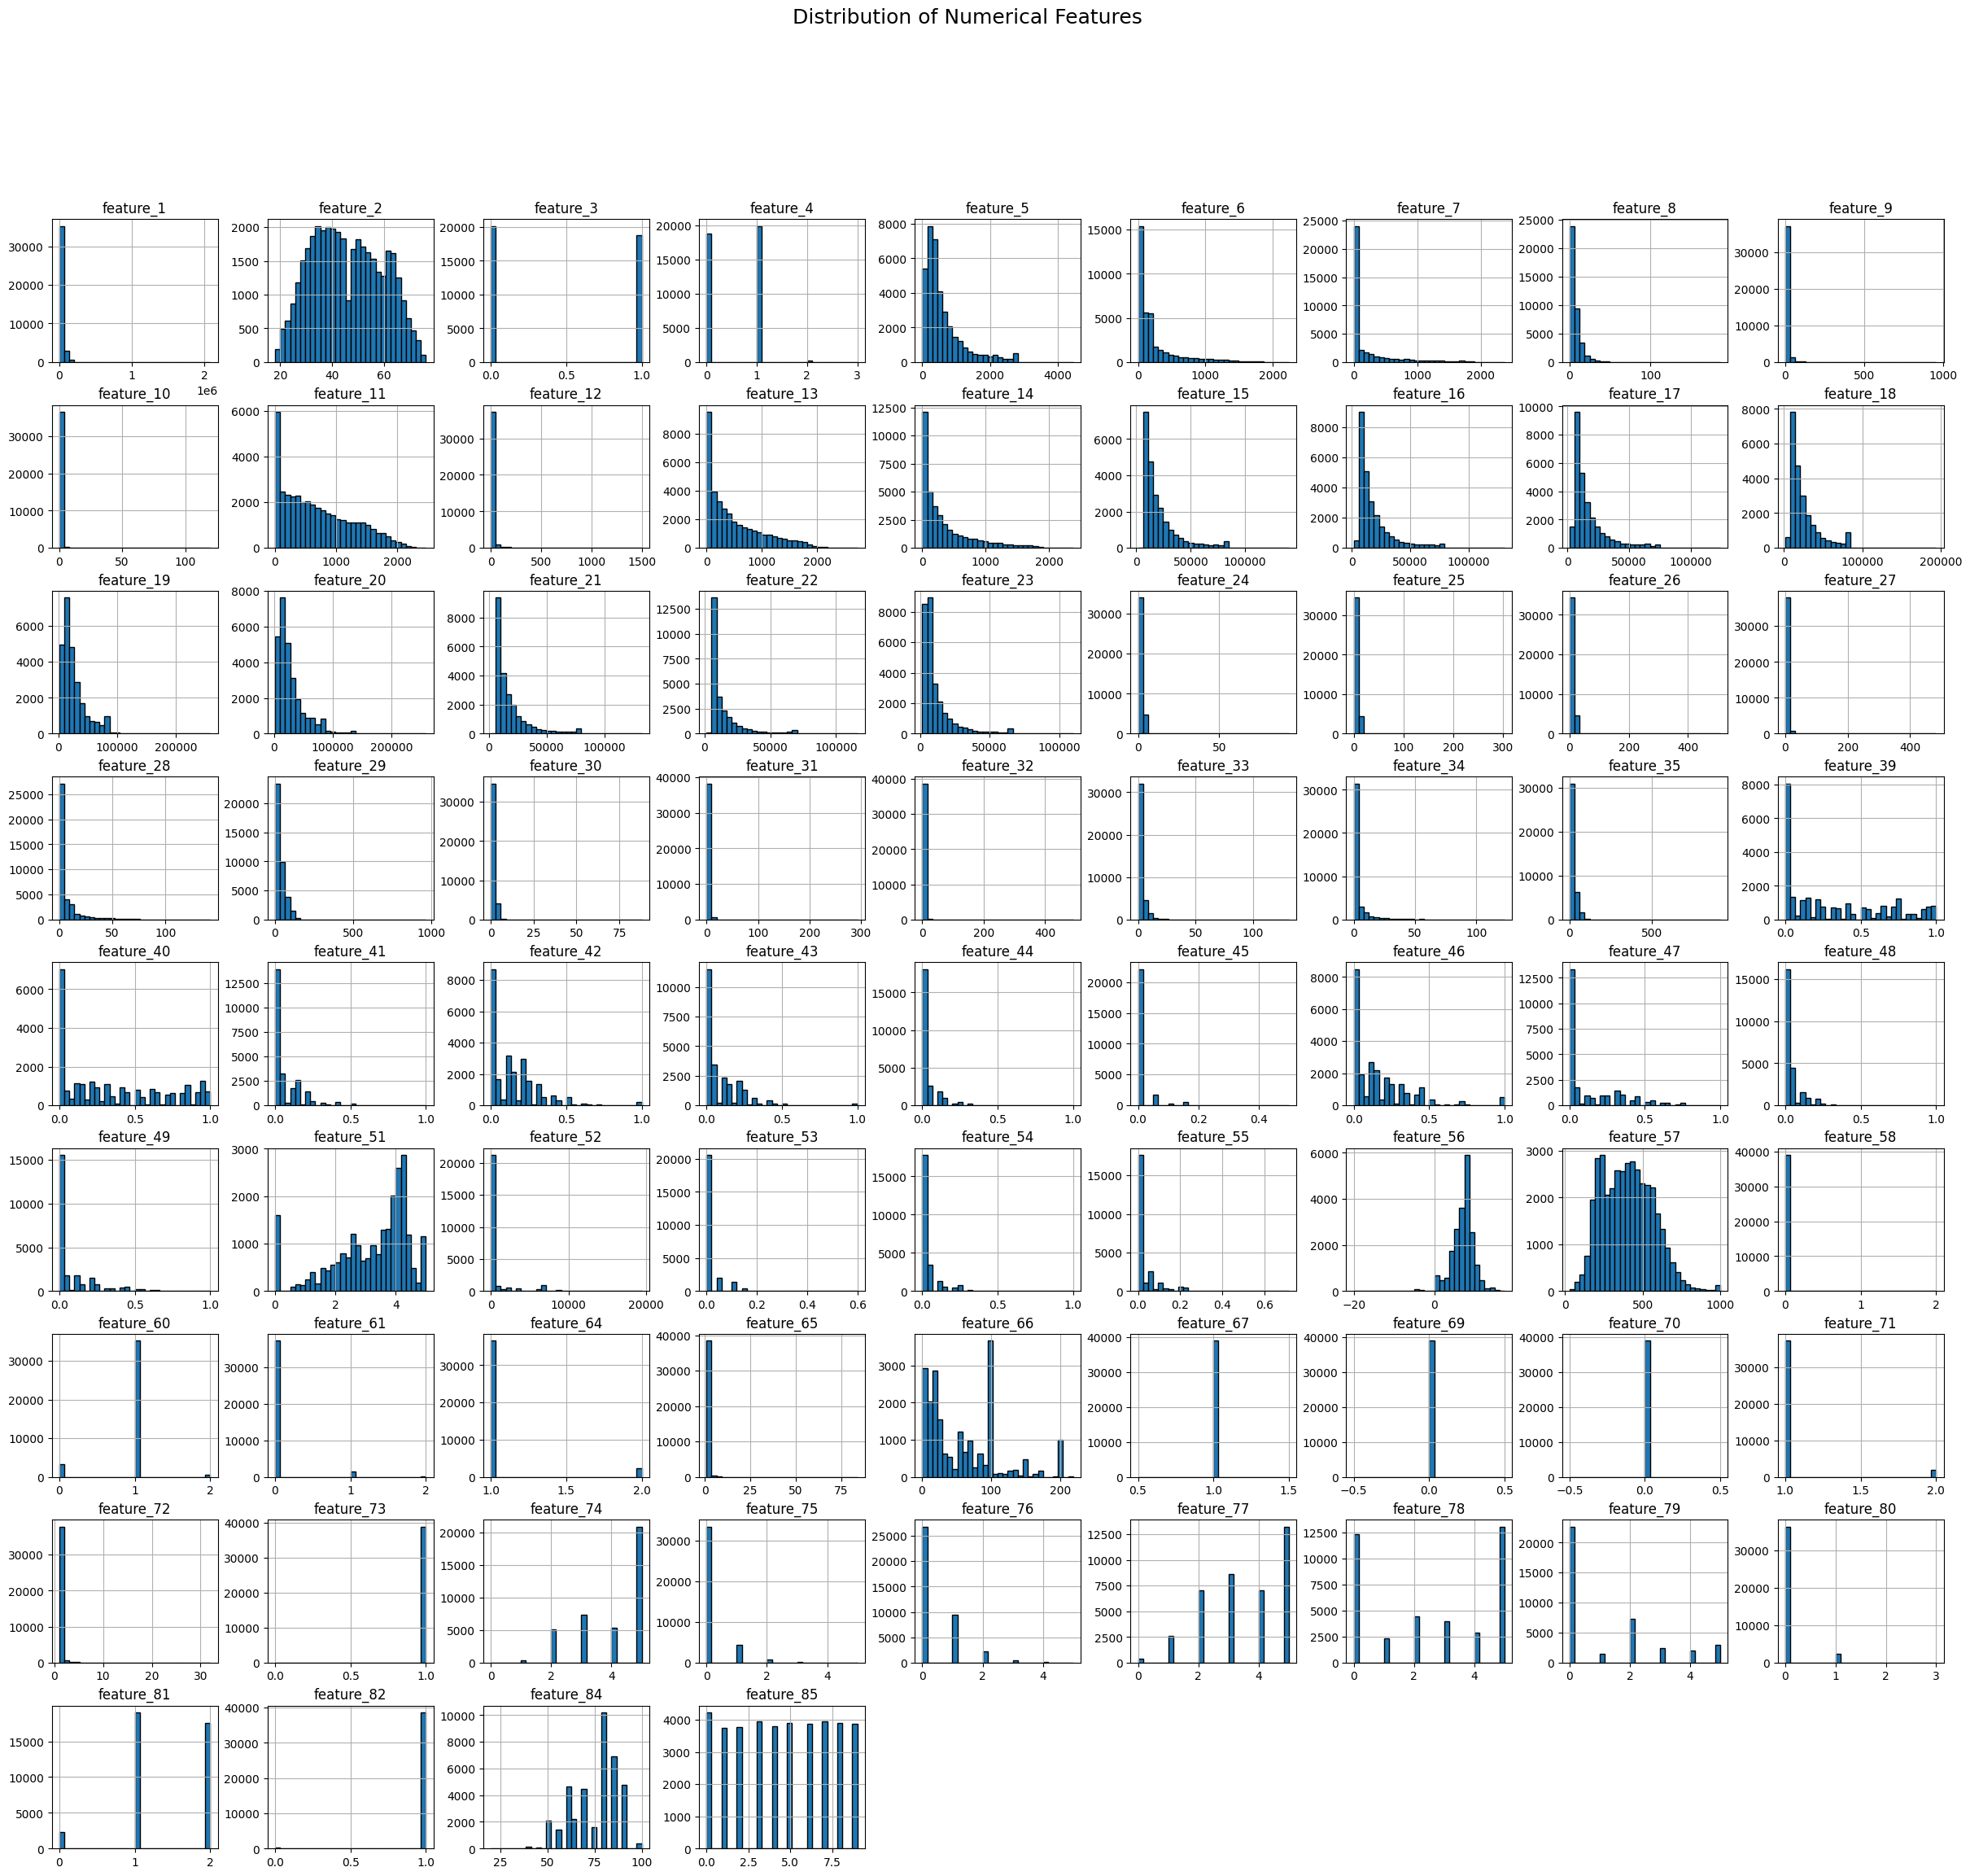

In [ ]:
# Re-define num_cols to ensure it's available
num_cols = df_clean.drop(columns=[TARGET]).select_dtypes(include=["int64", "float64"]).columns.tolist()

# Generating histograms for all numerical features
df_clean[num_cols].hist(
    figsize=(30, 26),
    bins=30,
    edgecolor="black"
)
plt.suptitle("Distribution of Numerical Features", fontsize=18)
plt.show()

Skewness - will help identify heavy tails and extreme values

In [ ]:
skew_values = df_clean.drop(columns=[TARGET]).skew(numeric_only=True).sort_values(ascending=False)

print("Top 10 positively skewed features:")
display(skew_values.head(10))

print("Top 10 negatively skewed features:")
display(skew_values.tail(10))


Top 10 positively skewed features:


,0
feature_58,124.310721
feature_10,29.902026
feature_65,29.880469
feature_32,25.446133
feature_31,25.356866
feature_27,21.857492
feature_30,18.699198
feature_9,16.935417
feature_25,13.671420
feature_26,13.369911


Top 10 negatively skewed features:


,0
feature_81,-0.415969
feature_77,-0.420712
feature_84,-0.592046
feature_74,-0.788398
feature_51,-0.973106
feature_56,-1.351899
feature_60,-1.843150
feature_62,-6.500160
feature_82,-9.873923
feature_73,-20.626237


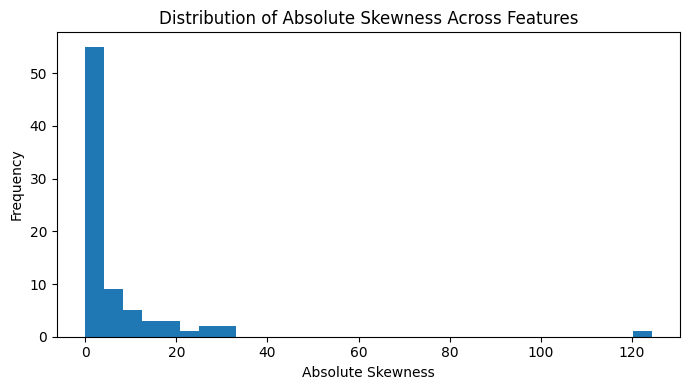

In [ ]:
# Overall distribution of absolute skewness
plt.figure(figsize=(7, 4))
skew_values.abs().plot(kind="hist", bins=30)
plt.title("Distribution of Absolute Skewness Across Features")
plt.xlabel("Absolute Skewness")
plt.tight_layout()
plt.show()

Correlation with Target - can be usefeul when features work togther

Top correlations with target:


,target
target,1.000000
feature_71,0.054917
feature_72,0.039572
feature_10,0.030613
feature_8,0.029243
feature_81,0.027706
feature_75,0.023282
feature_64,0.021169
feature_3,0.020641
feature_33,0.020430


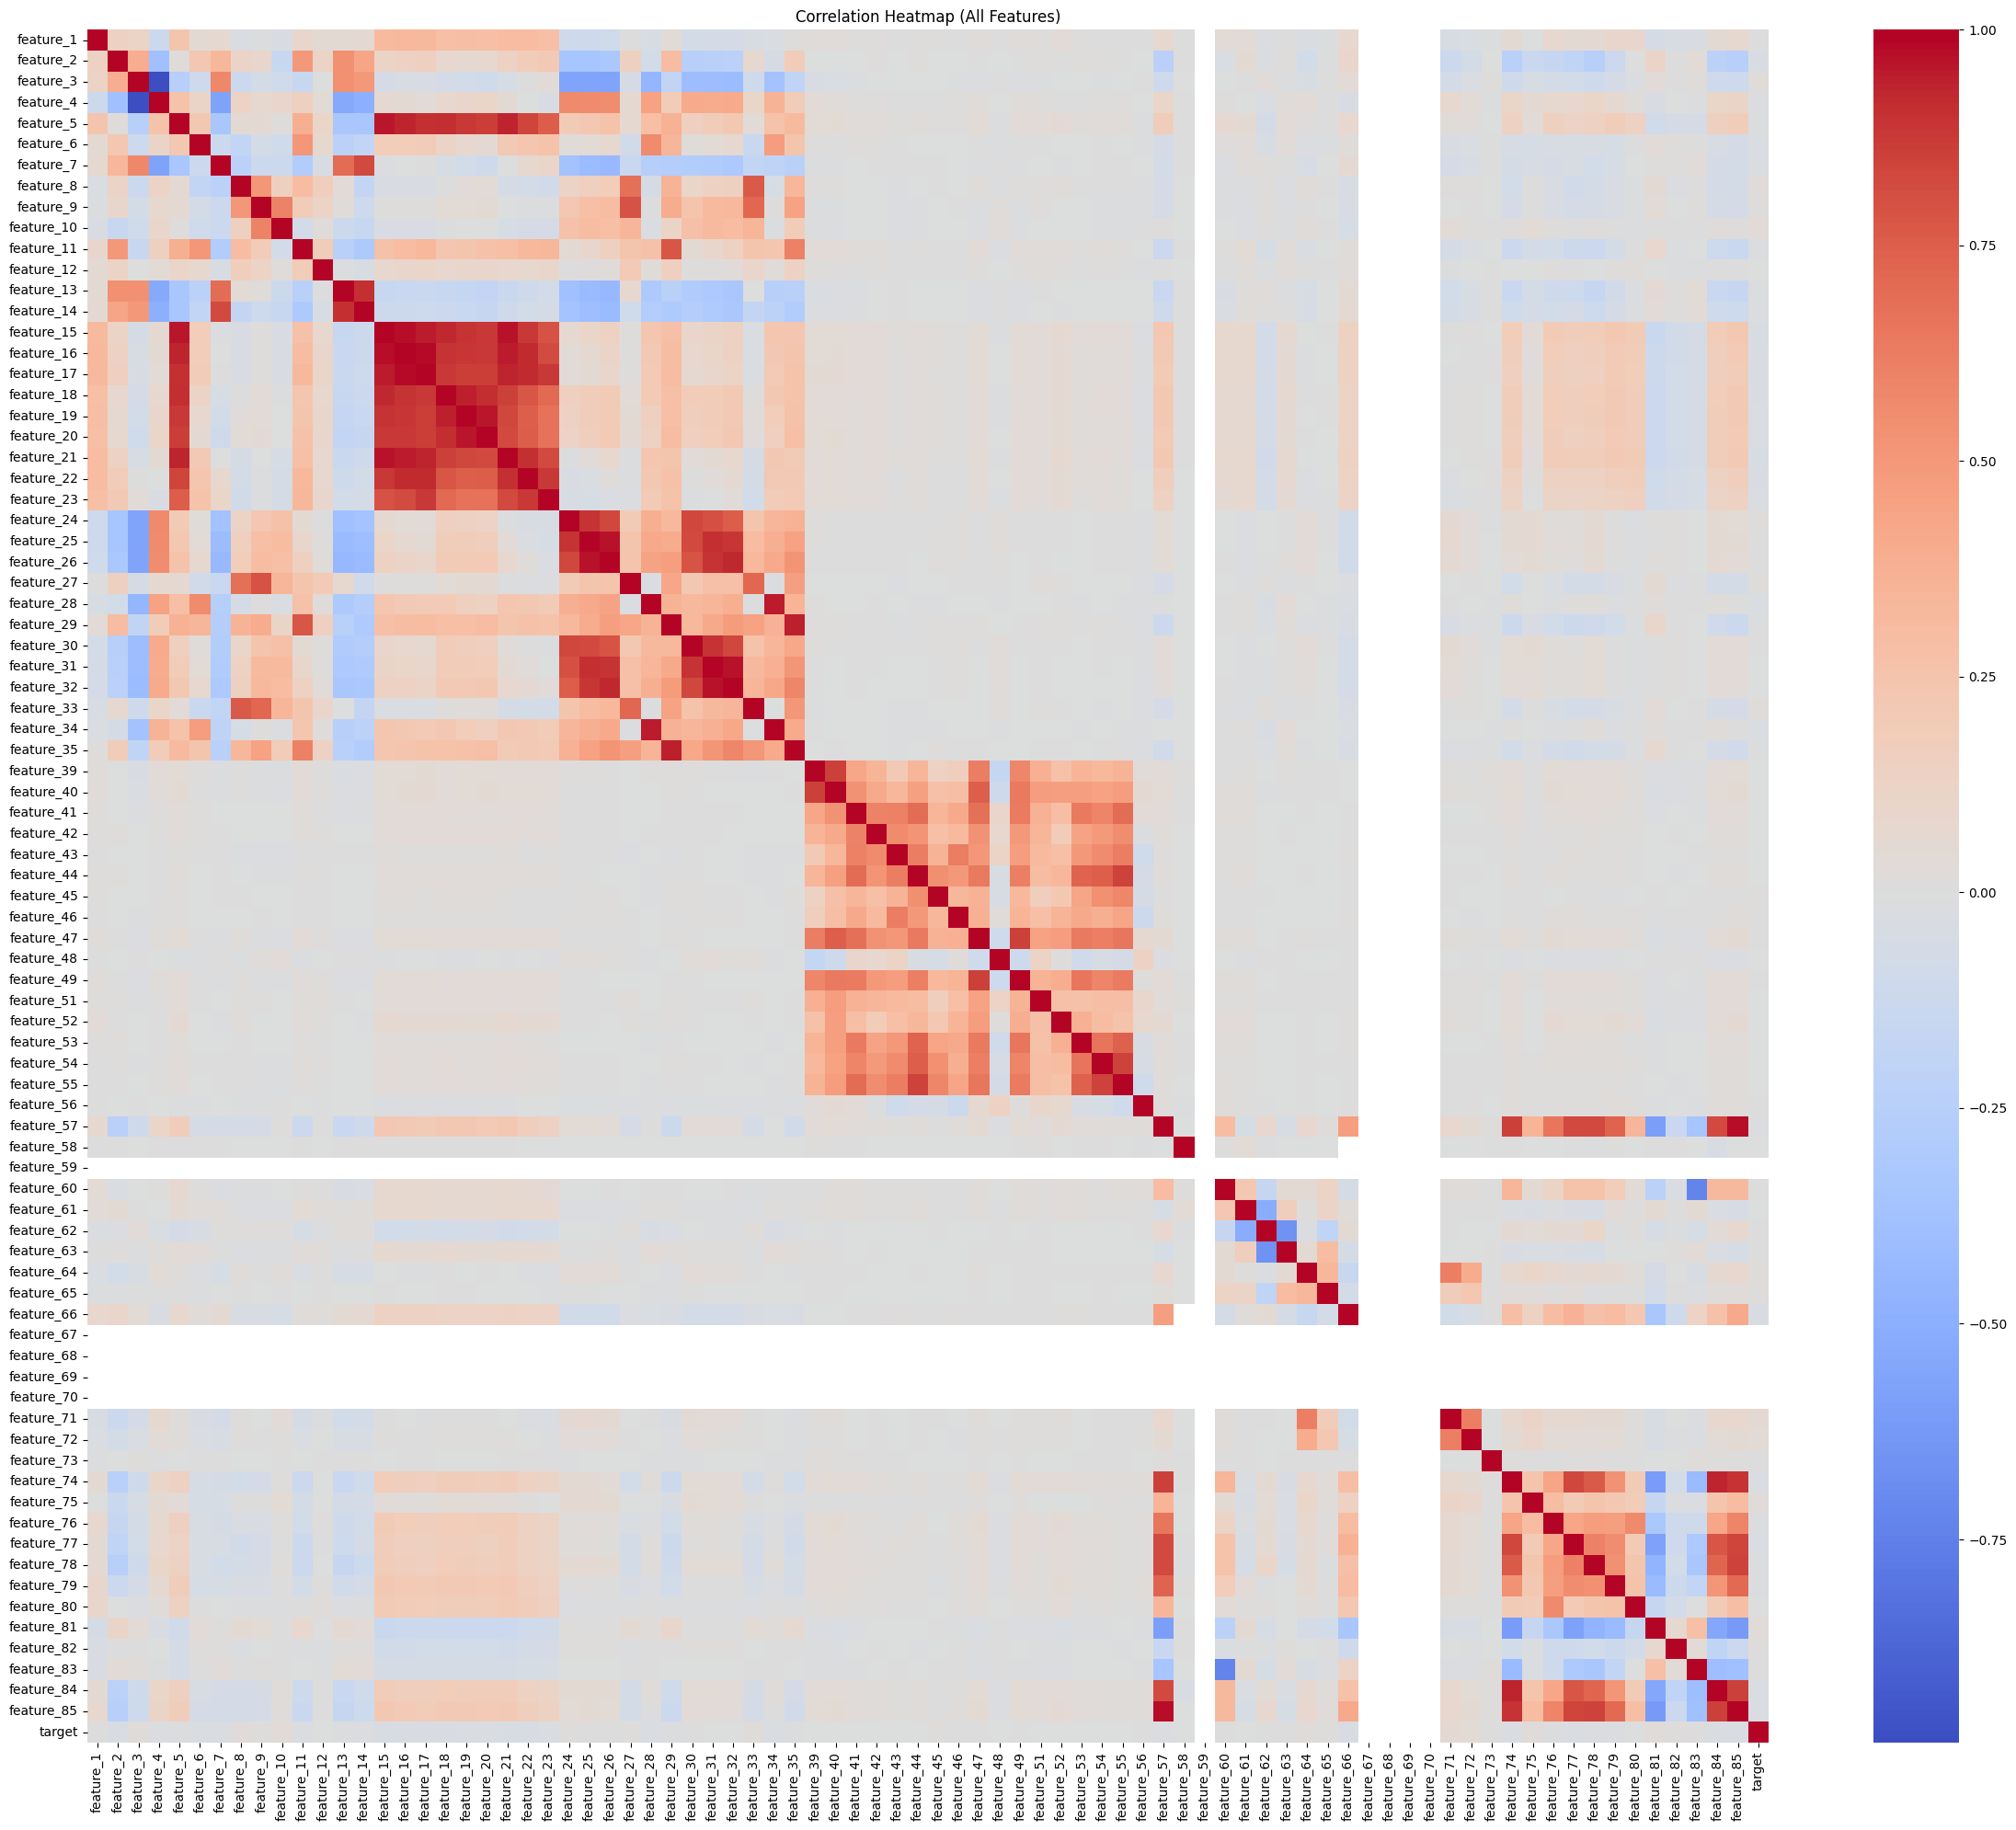

In [ ]:
corr_with_target = df_clean.corr(numeric_only=True)[TARGET].sort_values(ascending=False)
print("Top correlations with target:")
display(corr_with_target.head(15))

#correlation heatmap for all features
corr_matrix = df_clean.corr(numeric_only=True)

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (All Features)")
plt.tight_layout()
plt.show()

# Class Imbalance

,count,percent
target,,
0,37857,97.11
1,1128,2.89


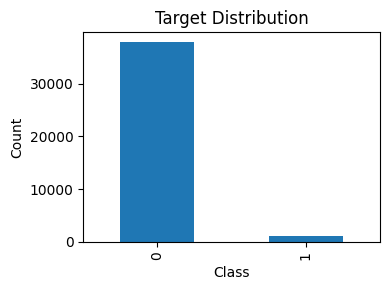

In [ ]:
target_counts = df_clean[TARGET].value_counts()
target_percent = (target_counts / len(df_clean) * 100).round(2)

display(pd.DataFrame({"count": target_counts, "percent": target_percent}))

plt.figure(figsize=(4, 3))
target_counts.plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# Preprocessing

Standardized Mean difference (SMD) - compares feature values between class 0 and class 1 on standarized scale so it can help spot feature that differ

,0
feature_71,0.327618
feature_21,0.244224
feature_72,0.236074
feature_15,0.234585
feature_66,0.217738
feature_2,0.213384
feature_18,0.208479
feature_16,0.203770
feature_22,0.194680
feature_17,0.184423


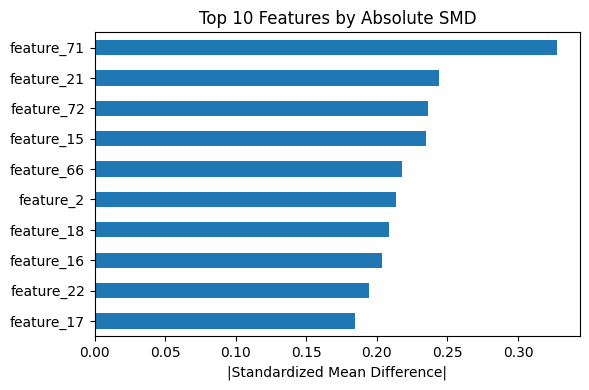

In [ ]:
feature_cols = [c for c in df_clean.columns if c != TARGET]

mean_0 = df_clean[df_clean[TARGET] == 0][feature_cols].mean(numeric_only=True)
mean_1 = df_clean[df_clean[TARGET] == 1][feature_cols].mean(numeric_only=True)

std_all = df_clean[feature_cols].std(numeric_only=True)
smd = (mean_1 - mean_0) / std_all

smd_abs = smd.abs().sort_values(ascending=False)
display(smd_abs.head(10))

plt.figure(figsize=(6, 4))
smd_abs.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Features by Absolute SMD")
plt.xlabel("|Standardized Mean Difference|")
plt.tight_layout()
plt.show()

In [ ]:

# Keeping these steps in a pipeline reduces leakage and makes results reproducible

from statsmodels. stats.outliers_influence import variance_inflation_factor

# keeping only numerical columns
X_num = df.drop(columns=["target"]).select_dtypes(include=["int64", "float64", "bool"]).copy()

# Converting bool to int 1/0
X_num = X_num.astype(float)

# Temporarily filling the missing values with median only for VIF
X_num = X_num.fillna(X_num.median())

# Compute VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X_num.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_num.values, i)
    for i in range(X_num.shape[1])
]

vif_data.sort_values("VIF", ascending=False).head(15)

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,feature,VIF
14,feature_15,51.009780
2,feature_3,39.620072
25,feature_26,39.425342
3,feature_4,38.614267
15,feature_16,37.861621
24,feature_25,36.502195
31,feature_32,36.481723
30,feature_31,34.569796
84,feature_85,33.381389
56,feature_57,29.688154


After going through the dataset, I saw that it has 38,985 rows and mostly numeric features, along with a few boolean variables. The only non-numeric column was the ID, which I removed since it doesn’t help with prediction. Some features have a fair amount of missing data (around 27–40%), but none are above 50%, so I decided to keep them and handle the missing values later during preprocessing. A lot of the features are highly skewed, which suggests there are some extreme values, which makes sense in a financial dataset. The individual correlations with the target are small, so it looks like no single feature strongly predicts default on its own. The target is also very imbalanced (about 97% non-default vs. 3% default), so accuracy alone wouldn’t be a good metric. Overall, the data seems workable, but it will need careful preprocessing and evaluation, especially because of the class imbalance.

## Data Splitting

In [ ]:
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

#split off test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y)

# split remaining into train (70%) and validation (15%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,  # 0.1765 of 85% ≈ 15% overall
    random_state=42,
    stratify=y_temp)

print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)

def show_balance(y_series, name):
    counts = y_series.value_counts()
    perc = (counts / len(y_series) * 100).round(2)
    print(f"\n{name} distribution:")
    display(pd.DataFrame({"count": counts, "percent": perc}))

show_balance(y_train, "Train")
show_balance(y_val, "Validation")
show_balance(y_test, "Test")

Train: (27288, 81) Validation: (5849, 81) Test: (5848, 81)

Train distribution:


,count,percent
target,,
0,26498,97.1
1,790,2.9



Validation distribution:


,count,percent
target,,
0,5680,97.11
1,169,2.89



Test distribution:


,count,percent
target,,
0,5679,97.11
1,169,2.89


I split the dataset into training (70%), validation (15%), and test (15%) sets using stratified sampling so the class imbalance would stay consistent across all three. After splitting, the class distribution remained almost identical in each set, with about 97% non-default and 3% default cases. This is important because it ensures the validation and test results reflect the real distribution of the data and prevents any imbalance issues caused by uneven splitting.

Imputation and standarization

In [ ]:
print("Total missing values in X_train:", X_train.isna().sum().sum())

#Imputing the missing values with the median
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_val_imp = imputer.transform(X_val)
X_test_imp = imputer.transform(X_test)

#Standardizing so mean=0, std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)
X_test_scaled = scaler.transform(X_test_imp)


Total missing values in X_train: 278027


# Feature selection

Here we reduce noise and improve generalization by selecting or prioritizing useful features. Feature selection can speed up training, reduce overfitting, and make the model easier to interpret.

In [ ]:
#L1 regularization

from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

# split off test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y)

# split remaining into train (70%) and validation (15%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,
    random_state=42,
    stratify=y_temp)


imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_val_imp = imputer.transform(X_val)
X_test_imp = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)
X_test_scaled = scaler.transform(X_test_imp)

# L1 penalty forces some coefficients to become exactly zero
l1_selector = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.1,              # smaller C = stronger regularization
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

# Fit only on training data
l1_selector.fit(X_train_scaled, y_train)

# Get coefficients
coef = l1_selector.coef_[0]

# Keep only features with non-zero coefficients
selected_mask = coef != 0


X_train_selected = X_train_scaled[:, selected_mask]
X_val_selected = X_val_scaled[:, selected_mask]
X_test_selected = X_test_scaled[:, selected_mask]


selected_features = X.columns[selected_mask]

print("Number of selected features:", len(selected_features))
print("Selected features:")
print(selected_features)

Number of selected features: 68
Selected features:
Index(['feature_1', 'feature_2', 'feature_4', 'feature_5', 'feature_6',
       'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11',
       'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16',
       'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22',
       'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27',
       'feature_29', 'feature_30', 'feature_31', 'feature_33', 'feature_34',
       'feature_35', 'feature_39', 'feature_40', 'feature_41', 'feature_42',
       'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47',
       'feature_48', 'feature_49', 'feature_51', 'feature_53', 'feature_54',
       'feature_56', 'feature_58', 'feature_60', 'feature_61', 'feature_62',
       'feature_63', 'feature_64', 'feature_65', 'feature_66', 'feature_71',
       'feature_72', 'feature_73', 'feature_74', 'feature_75', 'feature_77',
       'feature_78', 'feature_79'

In [ ]:
#consistent model evaluation
from sklearn.metrics import f1_score

def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n=== {name} ===")
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))
    print("PR-AUC:", average_precision_score(y_true, y_prob))
    print("F1:", f1_score(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))


# Classification Models

In [ ]:
#Logistic Regression
log_model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
log_model.fit(X_train_selected, y_train)

log_val_pred = log_model.predict(X_val_selected)
log_val_probs = log_model.predict_proba(X_val_selected)[:, 1]

evaluate_model("Logistic Regression", y_val, log_val_pred, log_val_probs)





=== Logistic Regression ===
ROC-AUC: 0.6502635636303026
PR-AUC: 0.06807219107708125
F1: 0.08071367884451996

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.63      0.77      5680
           1       0.04      0.56      0.08       169

    accuracy                           0.63      5849
   macro avg       0.51      0.60      0.42      5849
weighted avg       0.95      0.63      0.75      5849


Confusion Matrix:
 [[3590 2090]
 [  74   95]]


Logistic Regression shows moderate performance with a ROC-AUC of around 0.64. It was able to correctly identify more than half of the default cases recall = 57%, but the precision is very low at around 4%, meaning most predicted defaults are actually non-defaults.

In [ ]:
#SVM
svm_model = LinearSVC(class_weight="balanced", random_state=42, max_iter=10000)
svm_model.fit(X_train_selected, y_train)

svm_val_pred = svm_model.predict(X_val_selected)
svm_val_scores = svm_model.decision_function(X_val_selected)

evaluate_model("SVM", y_val, svm_val_pred, svm_val_scores)




=== SVM ===
ROC-AUC: 0.6503948245687141
PR-AUC: 0.06622108565808557
F1: 0.07952622673434856

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.63      0.77      5680
           1       0.04      0.56      0.08       169

    accuracy                           0.63      5849
   macro avg       0.51      0.59      0.42      5849
weighted avg       0.95      0.63      0.75      5849


Confusion Matrix:
 [[3579 2101]
 [  75   94]]


The Linear SVM performs almost the same as Logistic Regression. It achieves similar ROC-AUC and recall, but precision remains very low. Overall, it does not provide a noticeable improvement compared to logistic regression and behaves similarly in how it handles the imbalance.

In [ ]:
# XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)
xgb_model.fit(X_train_selected, y_train)

xgb_val_pred = xgb_model.predict(X_val_selected)
xgb_val_probs = xgb_model.predict_proba(X_val_selected)[:, 1]

evaluate_model("XGBoost", y_val, xgb_val_pred, xgb_val_probs)



scale_pos_weight: 33.54177215189873

=== XGBoost ===
ROC-AUC: 0.6160586298858238
PR-AUC: 0.050962935071001594
F1: 0.09441233140655106

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.86      0.91      5680
           1       0.06      0.29      0.09       169

    accuracy                           0.84      5849
   macro avg       0.52      0.57      0.50      5849
weighted avg       0.95      0.84      0.89      5849


Confusion Matrix:
 [[4860  820]
 [ 120   49]]


XGBoost performs slightly differently compared to the linear models. It produces slightly higher precision than logistic regression but identifies fewer default cases overall. This means it is more conservative and misses more defaults, trading off recall for slightly better precision.

In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic", "SVM", "XGBoost"],
    "ROC-AUC": [0.6387, 0.6380, 0.6239],
    "PR-AUC": [0.0588, 0.0589, 0.0522]
})

comparison_df

,Model,ROC-AUC,PR-AUC
0,Logistic,0.6387,0.0588
1,SVM,0.6380,0.0589
2,XGBoost,0.6239,0.0522


I trained Logistic Regression, Linear SVM, and XGBoost and compared them on the validation set. Logistic and SVM performed almost identically, both achieving around 0.64 ROC-AUC and identifying over half of the default cases, but with low precision. XGBoost had slightly better precision but lower recall. Based on validation performance, Logistic Regression and SVM performed more consistently for identifying default cases.

# Parameter Opitimization

In [ ]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# We'll tune using F1 so we balance precision + recall (instead of only PR-AUC)
from sklearn.metrics import make_scorer, f1_score
f1_scorer = make_scorer(f1_score)

In [ ]:
# Tune Logistic (C)
log_base = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
log_param_dist = {"C": np.logspace(-3, 1, 20)}

log_search = RandomizedSearchCV(
    log_base,
    param_distributions=log_param_dist,
    n_iter=10,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
log_search.fit(X_train_selected, y_train)
best_log = log_search.best_estimator_

print("Best Logistic params:", log_search.best_params_)
print("Best CV F1:", log_search.best_score_)

log_val_pred = best_log.predict(X_val_selected)
log_val_probs = best_log.predict_proba(X_val_selected)[:, 1]
evaluate_model("Tuned Logistic", y_val, log_val_pred, log_val_probs)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Logistic params: {'C': np.float64(0.001)}
Best CV F1: 0.08058819096839655

=== Tuned Logistic ===
ROC-AUC: 0.6639042836903075
PR-AUC: 0.06957991716087748
F1: 0.08466051969823973

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.63      0.77      5680
           1       0.05      0.60      0.08       169

    accuracy                           0.63      5849
   macro avg       0.51      0.61      0.43      5849
weighted avg       0.95      0.63      0.75      5849


Confusion Matrix:
 [[3564 2116]
 [  68  101]]


In [ ]:
# Tune Linear SVM (C)
svm_base = LinearSVC(class_weight="balanced", random_state=42, max_iter=10000)
svm_param_dist = {"C": [0.01, 0.1, 1, 5, 10]}

svm_search = RandomizedSearchCV(
    svm_base,
    param_distributions=svm_param_dist,
    n_iter=5,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
svm_search.fit(X_train_selected, y_train)
best_svm = svm_search.best_estimator_

print("Best SVM params:", svm_search.best_params_)
print("Best CV F1:", svm_search.best_score_)

svm_val_pred = best_svm.predict(X_val_selected)
svm_val_scores = best_svm.decision_function(X_val_selected)
evaluate_model("Tuned Linear SVM", y_val, svm_val_pred, svm_val_scores)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best SVM params: {'C': 0.01}
Best CV F1: 0.07827086545074274

=== Tuned Linear SVM ===
ROC-AUC: 0.6520866322193516
PR-AUC: 0.0664367712015495
F1: 0.08061094611794654

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.63      0.77      5680
           1       0.04      0.56      0.08       169

    accuracy                           0.63      5849
   macro avg       0.51      0.60      0.42      5849
weighted avg       0.95      0.63      0.75      5849


Confusion Matrix:
 [[3587 2093]
 [  74   95]]


In [ ]:
# Tune XGBoost (small search)
xgb_base = XGBClassifier(
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)
xgb_param_dist = {
    "n_estimators": [200, 400, 600],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.03, 0.05, 0.1]
}

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=10,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
xgb_search.fit(X_train_selected, y_train)
best_xgb = xgb_search.best_estimator_

print("Best XGB params:", xgb_search.best_params_)
print("Best CV F1:", xgb_search.best_score_)

xgb_val_pred = best_xgb.predict(X_val_selected)
xgb_val_probs = best_xgb.predict_proba(X_val_selected)[:, 1]
evaluate_model("Tuned XGBoost", y_val, xgb_val_pred, xgb_val_probs)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGB params: {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.05}
Best CV F1: 0.09654871271441368

=== Tuned XGBoost ===
ROC-AUC: 0.6160586298858238
PR-AUC: 0.050962935071001594
F1: 0.09441233140655106

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.86      0.91      5680
           1       0.06      0.29      0.09       169

    accuracy                           0.84      5849
   macro avg       0.52      0.57      0.50      5849
weighted avg       0.95      0.84      0.89      5849


Confusion Matrix:
 [[4860  820]
 [ 120   49]]


# Class Imbalance after SMOTE

SMOTE PR-AUC: 0.0448
Weighted PR-AUC: 0.0377


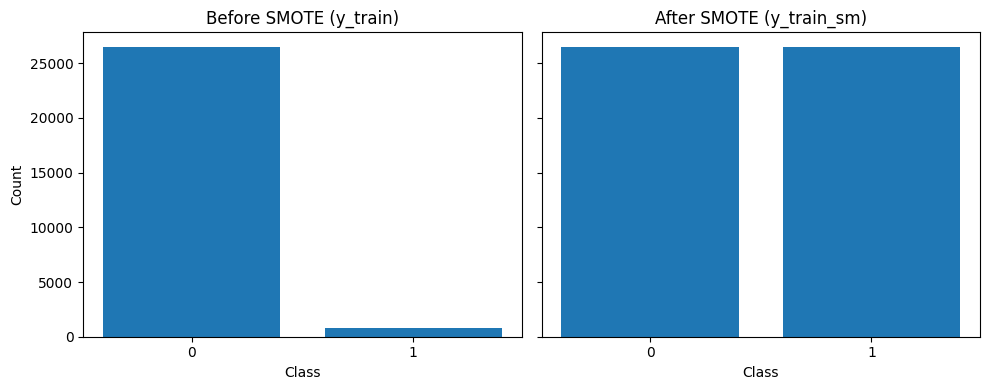

In [ ]:
# Addressing Class Imbalance


from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_selected, y_train)


# Instead of changing the data, we tell the model to pay more attention to fraud cases.
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()

# Train both to compare
model_smote = XGBClassifier(random_state=42).fit(X_train_sm, y_train_sm)
model_weighted = XGBClassifier(scale_pos_weight=imbalance_ratio, random_state=42).fit(X_train_selected, y_train)

# Evaluation Comparison
print(f"SMOTE PR-AUC: {average_precision_score(y_val, model_smote.predict_proba(X_val_selected)[:, 1]):.4f}")
print(f"Weighted PR-AUC: {average_precision_score(y_val, model_weighted.predict_proba(X_val_selected)[:, 1]):.4f}")
import matplotlib.pyplot as plt

# Count classes before SMOTE
before_counts = y_train.value_counts().sort_index()

# Count classes after SMOTE
after_counts = y_train_sm.value_counts().sort_index()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].bar(before_counts.index.astype(str), before_counts.values)
axes[0].set_title("Before SMOTE (y_train)")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

axes[1].bar(after_counts.index.astype(str), after_counts.values)
axes[1].set_title("After SMOTE (y_train_sm)")
axes[1].set_xlabel("Class")

plt.tight_layout()
plt.show()

# Threshold Tuning

In [ ]:
from sklearn.metrics import precision_score, recall_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd

from sklearn.metrics import f1_score

def choose_threshold_f1(y_true, y_prob):
    thresholds = np.arange(0.05, 0.95, 0.01)
    best_t = 0.5
    best_f1 = -1

    for t in thresholds:
        preds = (y_prob >= t).astype(int)
        score = f1_score(y_true, preds)

        if score > best_f1:
            best_f1 = score
            best_t = t

    return best_t, best_f1


final_model = best_xgb

val_probs = final_model.predict_proba(X_val_selected)[:, 1]

# F1-based threshold (balances precision + recall)
best_t, best_f1 = choose_threshold_f1(y_val, val_probs)

print("Chosen threshold (max F1):", best_t)
print("Best F1 on validation:", best_f1)

val_pred = (val_probs >= best_t).astype(int)
evaluate_model("Final model on Validation (F1 threshold)", y_val, val_pred, val_probs)


Chosen threshold (max F1): 0.4700000000000001
Best F1 on validation: 0.09693053311793215

=== Final model on Validation (F1 threshold) ===
ROC-AUC: 0.6160586298858238
PR-AUC: 0.050962935071001594
F1: 0.09693053311793215

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.82      0.89      5680
           1       0.06      0.36      0.10       169

    accuracy                           0.81      5849
   macro avg       0.52      0.59      0.50      5849
weighted avg       0.95      0.81      0.87      5849


Confusion Matrix:
 [[4671 1009]
 [ 109   60]]


# Global Explaninability

Top 10 Most Important Features (Feature Importance):


,Feature,Value,Abs_Value
1,feature_2,0.024784,0.024784
63,feature_81,0.021306,0.021306
8,feature_10,0.020492,0.020492
55,feature_72,0.020271,0.020271
54,feature_71,0.019400,0.019400
35,feature_43,0.019120,0.019120
5,feature_7,0.018620,0.018620
21,feature_24,0.017831,0.017831
64,feature_82,0.017703,0.017703
2,feature_4,0.017267,0.017267


<Figure size 700x400 with 0 Axes>

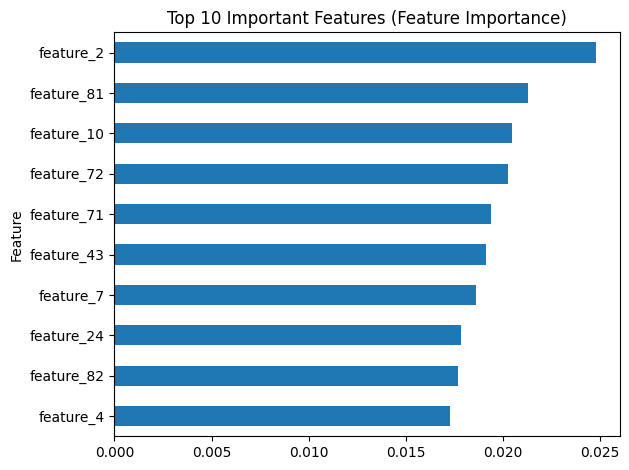

In [ ]:
# Feature Importance (works for both Linear and Tree models)

if hasattr(final_model, "feature_importances_"):
    # For Tree models (XGBoost, Random Forest)
    importances = final_model.feature_importances_
    metric_name = "Feature Importance"
else:
    # For Linear models (Logistic Regression, SVM)
    importances = final_model.coef_[0]
    metric_name = "Coefficient Magnitude"

importance_df = pd.DataFrame({
    "Feature": selected_features,
    "Value": importances,
    "Abs_Value": np.abs(importances)
}).sort_values("Abs_Value", ascending=False)

print(f"Top 10 Most Important Features ({metric_name}):")
display(importance_df.head(10))

plt.figure(figsize=(7, 4))
importance_df.head(10).sort_values("Abs_Value").plot(
    x="Feature", y="Abs_Value", kind="barh", legend=False
)
plt.title(f"Top 10 Important Features ({metric_name})")
plt.tight_layout()
plt.show()

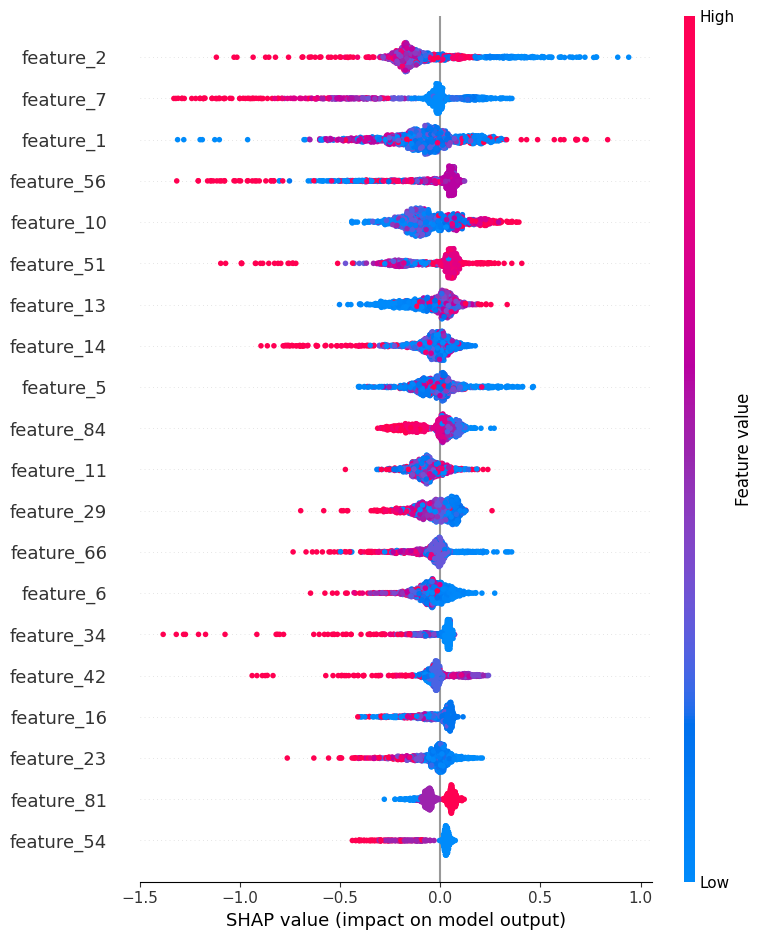

In [ ]:
# SHAP summary plot (tree model) — keep sample small so it runs fast
sample_size = 1000
X_sample = X_train_selected[:sample_size]

tree_model = best_xgb  # switch to best_rf if you prefer

explainer = shap.TreeExplainer(tree_model)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample, feature_names=selected_features)


In [ ]:
test_probs = final_model.predict_proba(X_test_selected)[:, 1]
test_pred = (test_probs >= best_t).astype(int)

evaluate_model("FINAL TEST RESULTS", y_test, test_pred, test_probs)



=== FINAL TEST RESULTS ===
ROC-AUC: 0.6388938380892545
PR-AUC: 0.06578142858965348
F1: 0.0990916597853014

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.83      0.90      5679
           1       0.06      0.36      0.10       169

    accuracy                           0.81      5848
   macro avg       0.52      0.59      0.50      5848
weighted avg       0.95      0.81      0.87      5848


Confusion Matrix:
 [[4697  982]
 [ 109   60]]


In [ ]:
#imporved test result
improved_test_probs = best_xgb_improved.predict_proba(X_test_selected)[:, 1]
improved_test_pred  = (improved_test_probs >= best_t_improved).astype(int)

evaluate_model('IMPROVED FINAL TEST RESULTS', y_test,
               improved_test_pred, improved_test_probs)


=== IMPROVED FINAL TEST RESULTS ===
ROC-AUC: 0.6162369197844023
PR-AUC: 0.042877650914183996
F1: 0.07018867924528302

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.58      0.73      5679
           1       0.04      0.55      0.07       169

    accuracy                           0.58      5848
   macro avg       0.51      0.56      0.40      5848
weighted avg       0.95      0.58      0.71      5848


Confusion Matrix:
 [[3291 2388]
 [  76   93]]
